<a href="https://colab.research.google.com/github/Alnico81/OPTMASI-APSO/blob/main/LDA_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gensim
!pip install pyLDAvis
import pandas as pd
import gensim
import gensim.corpora as corpora
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# ---------------------------------------------------------
# FASE 1: LOAD DATA & PERSIAPAN KORPUS
# ---------------------------------------------------------
print("1. Membaca Full Text Corpus...")
# Membaca kedua file parquet yang diberikan dan menggabungkannya
df_test = pd.read_parquet('/content/sample_data/test_data.parquet')
df_train = pd.read_parquet('/content/sample_data/train_data.parquet')
df = pd.concat([df_test, df_train], ignore_index=True)

# Asumsikan Anda memiliki kolom teks yang sudah bersih (setelah sastrawi/stopword).
# Ganti 'clean_text' dengan nama kolom asli Anda di dataset (misal: 'text_preprocessed')
df['clean_text'] = df['Review'].fillna('') # Corrected: 'clean_text' column is created from 'Review'

# Memecah kalimat menjadi token (list of words)
print("2. Melakukan Tokenisasi...")
data_words = [text.split() for text in df['clean_text'].tolist()]

# Membuat Kamus Kata (Dictionary) dan Bag-of-Words Corpus
id2word = corpora.Dictionary(data_words)

# (Opsional) Membuang kata yang terlalu jarang (muncul < 5 kali) atau terlalu sering (> 50% dokumen)
id2word.filter_extremes(no_below=5, no_above=0.5)

corpus = [id2word.doc2bow(text) for text in data_words]

# ---------------------------------------------------------
# FASE 2: PENENTUAN PARAMETER MANUAL (TEBAKAN MANUSIA)
# ---------------------------------------------------------
# Karena TANPA APSO, kita harus menebak angka ini sendiri secara manual
K_manual = 8                   # Mencoba 8 topik
alpha_manual = 'symmetric'     # Menggunakan settingan bawaan/default (bukan hasil optimasi)
beta_manual = 'symmetric'      # Menggunakan settingan bawaan/default (di gensim disebut 'eta')

print(f"\n3. Melatih Model LDA Manual (K={K_manual}, Alpha={alpha_manual}, Beta={beta_manual})...")

# ---------------------------------------------------------
# FASE 3: TRAINING MODEL LDA
# ---------------------------------------------------------
lda_model_manual = LdaModel(
    corpus=corpus,
    id2word=id2word,
    num_topics=K_manual,
    random_state=100,      # Mengunci seed agar hasil konsisten
    update_every=1,
    chunksize=100,
    passes=20,             # Jumlah putaran belajar (dinaikkan agar tidak underfitting)
    alpha=alpha_manual,
    eta=beta_manual,
    per_word_topics=True
)

# ---------------------------------------------------------
# FASE 4: MENAMPILKAN HASIL & SKOR KOHERENSI
# ---------------------------------------------------------
print("\n=== KATA KUNCI DOMINAN DARI LDA MANUAL ===")
for idx, topic in lda_model_manual.print_topics(-1):
    print(f"Topik {idx+1}: {topic}")

print("\n4. Menghitung Coherence Score (Cv)....")
coherence_model_lda = CoherenceModel(
    model=lda_model_manual,
    texts=data_words,
    dictionary=id2word,
    coherence='c_v'
)
coherence_lda_manual = coherence_model_lda.get_coherence()

# Menampilkan perbandingan (Asumsi skor APSO Anda sebelumnya adalah 0.2591)
print("--------------------------------------------------")
print(f"Skor Coherence LDA Manual  : {coherence_lda_manual:.4f}")
print("--------------------------------------------------")

# ---------------------------------------------------------
# FASE 5: VISUALISASI DENGAN pyLDAvis
# ---------------------------------------------------------
print("\n5. Membuat Visualisasi pyLDAvis...")
pyLDAvis.enable_notebook()
vis_data_manual = gensimvis.prepare(lda_model_manual, corpus, id2word)

# Menyimpan ke HTML untuk bukti di naskah Jurnal
pyLDAvis.save_html(vis_data_manual, 'hasil_lda_manual_baseline.html')
print("Selesai! Visualisasi disimpan sebagai 'hasil_lda_manual_baseline.html'")

# Menampilkan visualisasi langsung di Colab
vis_data_manual

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 30.1 MB/s eta 0:00:00
1. Membaca Full Text Corpus...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


2. Melakukan Tokenisasi...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


3. Melatih Model LDA Manual (K=8, Alpha=symmetric, Beta=symmetric)...


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Selesai! Visualisasi disimpan sebagai 'hasil_lda_manual_baseline.html'


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
7     -0.193463  0.084762       1        1  23.222506
0     -0.093646  0.037752       2        1  15.323517
6     -0.062555  0.018388       3        1  14.583380
3     -0.160091 -0.005758       4        1  12.357847
4     -0.009390  0.264391       5        1  11.238484
5      0.067019 -0.291472       6        1   9.349356
1      0.038748 -0.231828       7        1   7.635395
2      0.413377  0.123765       8        1   6.289514, topic_info=       Term          Freq         Total Category  logprob  loglift
90       yg  14924.000000  14924.000000  Default  30.0000  30.0000
312   cocok   8635.000000   8635.000000  Default  29.0000  29.0000
53    tidak  11099.000000  11099.000000  Default  28.0000  28.0000
120     nya  12251.000000  12251.000000  Default  27.0000  27.0000
259    saya   8076.000000   8076.000000  Default  26.0000  26.0000
..      ...           ...           ...      ...      ...      ...
460  nyaman    400.106174    401.012483   Topic8  -4.9402   2.7640
649  begitu    398.653535    399.558962   Topic8  -4.9439   2.7640
110   sampe   1204.601473   2078.182716   Topic8  -3.8381   2.2209
485     mau   1336.412067   3063.820850   Topic8  -3.7342   1.9366
278    pake    604.410995   3756.749985   Topic8  -4.5277   0.9392

[388 rows x 6 columns], token_table=      Topic      Freq  Term
term                       
772       2  0.999691     ,
561       8  0.999289     .
263       1  0.795158     1
263       5  0.204813     1
129       1  0.545359     2
...     ...       ...   ...
1351      7  0.998351   ya,
725       7  0.997822   yaa
304       1  0.812424  yang
304       3  0.187399  yang
90        1  0.999972    yg

[413 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[8, 1, 7, 4, 5, 6, 2, 3])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Ringkasan Parameter dan Hasil Model LDA Manual

In [ ]:
print(f"Jumlah Topik (K_manual): {K_manual}")
print(f"Parameter Alpha (alpha_manual): {alpha_manual}")
print(f"Parameter Beta (beta_manual): {beta_manual}")
print(f"Skor Koherensi (coherence_lda_manual): {coherence_lda_manual:.4f}")

Jumlah Topik (K_manual): 8
Parameter Alpha (alpha_manual): symmetric
Parameter Beta (beta_manual): symmetric
Skor Koherensi (coherence_lda_manual): 0.5570


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

### Word Cloud untuk Setiap Topik

Visualisasi ini menampilkan kata-kata kunci dominan untuk setiap topik dalam bentuk word cloud. Ukuran kata mencerminkan kepentingannya dalam topik tersebut.

Output streaming akan dipotong hingga 5000 baris terakhir.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow(

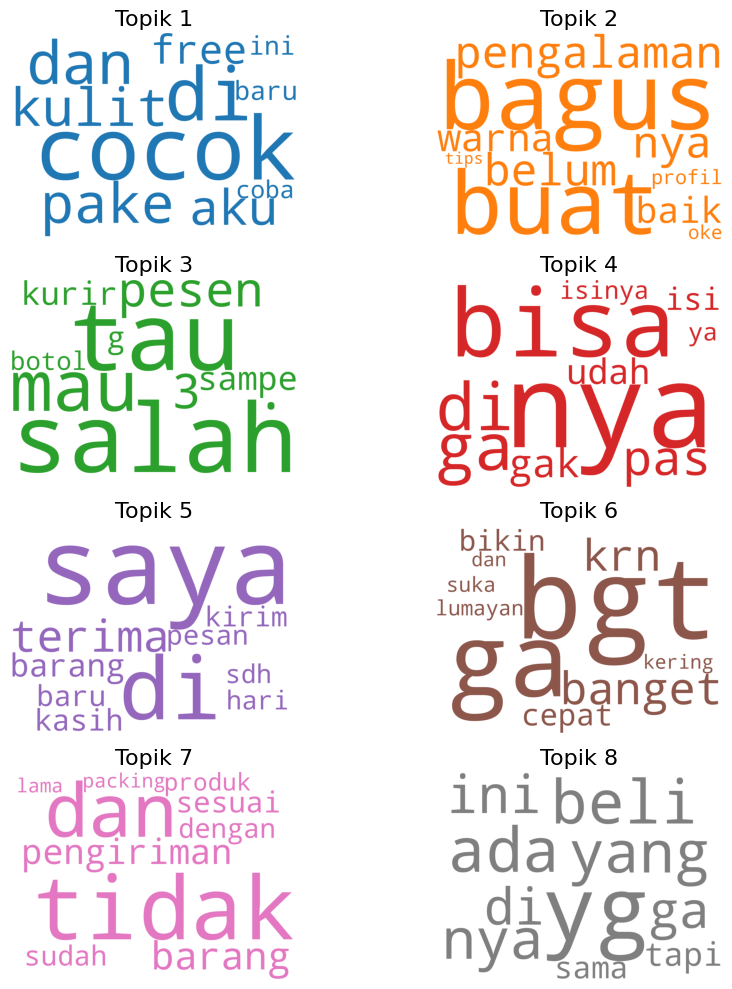

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [7]:
cols = plt.cm.tab10.colors

cloud = WordCloud(stopwords=[],
                  background_color='white',
                  width=2500,
                  height=1800,
                  max_words=10,
                  colormap='tab10',
                  color_func=lambda *args, **kwargs: tuple(int(c * 255) for c in cols[i]),
                  prefer_horizontal=1.0)

topics = lda_model_manual.show_topics(formatted=False)

fig, axes = plt.subplots(int(K_manual/2), 2, figsize=(10,10), sharex=True, sharey=True)

for i, ax in enumerate(axes.flatten()):
    if i < K_manual:
        # Extract words and their weights for the current topic
        topic_words_weights = dict(topics[i][1])
        cloud.generate_from_frequencies(topic_words_weights)
        ax.imshow(cloud)
        ax.set_title('Topik ' + str(i+1), fontdict=dict(size=16))
        ax.axis('off')

plt.tight_layout(w_pad=0)
plt.show()